# ML4QS Group 40 — Feature Engineering
**Wrist-Based Activity Recognition**  
Aniket Dasurkar, Mansi Saxena, Shreya Bhatt — Vrije Universiteit Amsterdam

This notebook extracts features from the cleaned sensor data produced by `02_preprocessing.ipynb`.

Features are extracted per **2-second sliding window with 50% overlap**, giving ~29 windows per 30s session.

Feature groups:
1. **Time domain** — mean, std, min, max, RMS, range, zero-crossing rate, signal magnitude area, interquartile range, skewness, kurtosis, mean absolute deviation, peak-to-peak
2. **Frequency domain** — dominant frequency, spectral energy, spectral entropy, spectral centroid, top-3 FFT magnitudes  
3. **Correlation features** — pairwise axis correlations within each sensor
4. **Magnitude features** — same time/freq features on acc_mag, gyr_mag, lin_mag

All features computed per window → one row per window → fed into classifier.


## 0 · Imports & Load Cleaned Data

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import skew, kurtosis
from scipy.fft import rfft, rfftfreq
from scipy.signal import welch

OUTPUT_DIR = Path("outputs/")
(OUTPUT_DIR / "features").mkdir(parents=True, exist_ok=True)
(OUTPUT_DIR / "eda").mkdir(parents=True, exist_ok=True)

ACTIVITIES  = ["smoking", "typing", "idle", "cooking", "exercising"]
SENSOR_COLS = ["acc_x","acc_y","acc_z",
               "gyr_x","gyr_y","gyr_z",
               "lin_x","lin_y","lin_z"]
MAG_COLS    = ["acc_mag","gyr_mag","lin_mag"]
ALL_SIGNAL_COLS = SENSOR_COLS + MAG_COLS
PALETTE     = dict(zip(ACTIVITIES,
                       ["#e63946","#457b9d","#6a994e","#e9c46a","#f4a261"]))

WINDOW_SIZE = 2.0   # seconds
STEP_SIZE   = 1.0   # seconds (50% overlap)
FS          = 50.0  # Hz after resampling

# Load cleaned data from preprocessing notebook
df = pd.read_parquet("outputs/features/cleaned_all.parquet")

# Make sure magnitude columns exist
df["acc_mag"] = np.sqrt(df["acc_x"]**2 + df["acc_y"]**2 + df["acc_z"]**2)
df["gyr_mag"] = np.sqrt(df["gyr_x"]**2 + df["gyr_y"]**2 + df["gyr_z"]**2)
df["lin_mag"] = np.sqrt(df["lin_x"]**2 + df["lin_y"]**2 + df["lin_z"]**2)

print(f"Loaded: {len(df):,} rows | {df['subject'].unique()} | columns: {df.columns.tolist()}")


Loaded: 180,423 rows | <ArrowStringArray>
['subject_1', 'subject_2', 'subject_3']
Length: 3, dtype: str | columns: ['time', 'acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z', 'lin_x', 'lin_y', 'lin_z', 'subject', 'activity', 'session', 'acc_mag', 'gyr_mag', 'lin_mag']


## 1 · Sliding Window Segmentation

**Why 2-second windows (ML4QS Ch. 4):**  
A window must be long enough to capture at least one full cycle of the slowest activity. Smoking has the slowest periodicity at ~0.4 Hz (one hand-to-mouth arc every ~2.5 s). A 2-second window captures most of one full gesture cycle while still giving ~29 windows per 30s session.

**Why 50% overlap:**  
Overlap increases the number of training samples without additional recording. At 50% overlap, each window shares half its data with its neighbours, which smooths the feature space and reduces the chance of a gesture being split across two non-overlapping windows.

> **Window size trade-off:** Larger windows capture more context but give fewer samples and may span activity transitions. Smaller windows give more samples but may miss slow gestures like smoking entirely.


In [2]:
def sliding_windows(df: pd.DataFrame,
                    window_size: float = WINDOW_SIZE,
                    step_size:   float = STEP_SIZE) -> list:
    """
    Slice each session into overlapping fixed-length windows.
    Returns a list of dicts: {data: np.array, label, subject, session}
    """
    windows = []

    for subject in df["subject"].unique():
        for activity in df["activity"].unique():
            for session in df["session"].unique():
                mask = (
                    (df["subject"]  == subject) &
                    (df["activity"] == activity) &
                    (df["session"]  == session)
                )
                grp = df[mask].copy().reset_index(drop=True)
                if len(grp) == 0:
                    continue

                time = grp["time"].values
                t    = time[0]

                while t + window_size <= time[-1]:
                    w_mask  = (time >= t) & (time < t + window_size)
                    window  = grp[w_mask]

                    if len(window) > 10:   # skip near-empty edge windows
                        windows.append({
                            "data":     window[ALL_SIGNAL_COLS].values,
                            "cols":     ALL_SIGNAL_COLS,
                            "label":    activity,
                            "subject":  subject,
                            "session":  session
                        })
                    t += step_size

    return windows


windows = sliding_windows(df)
print(f"Total windows : {len(windows):,}")
print(f"Expected      : ~{120 * 29:,}  (120 sessions × ~29 windows)")
print(f"Samples/window: {windows[0]['data'].shape[0]} rows × {windows[0]['data'].shape[1]} cols")

# Windows per activity
from collections import Counter
label_counts = Counter(w["label"] for w in windows)
print("\nWindows per activity:")
for act in ACTIVITIES:
    print(f"  {act:<12}: {label_counts[act]:,}")


Total windows : 3,360
Expected      : ~3,480  (120 sessions × ~29 windows)
Samples/window: 101 rows × 12 cols

Windows per activity:
  smoking     : 672
  typing      : 672
  idle        : 672
  cooking     : 672
  exercising  : 672


## 2 · Time-Domain Feature Extraction

Extracted **per axis** for all 12 signal columns (9 raw + 3 magnitude):

| Feature | What it captures |
|---|---|
| Mean | Average wrist position / tilt |
| Std | Variability of motion |
| Min / Max / Range | Extent of movement |
| RMS | Overall signal energy |
| Zero-crossing rate | How often motion direction reverses — high for typing |
| Signal magnitude area | Total integrated movement over the window |
| IQR | Spread robust to outliers |
| Skewness | Asymmetry — smoking has asymmetric up/down strokes |
| Kurtosis | Peakedness — impulsive motions (typing) vs smooth (smoking) |
| Mean absolute deviation | Average deviation from mean, robust to outliers |
| Peak-to-peak | Max swing amplitude |


In [3]:
def time_domain_features(signal: np.ndarray, col_name: str) -> dict:
    """Extract time-domain features from a 1D signal array."""
    f = {}
    c = col_name  # shorthand prefix

    f[f"{c}_mean"]   = np.mean(signal)
    f[f"{c}_std"]    = np.std(signal)
    f[f"{c}_min"]    = np.min(signal)
    f[f"{c}_max"]    = np.max(signal)
    f[f"{c}_range"]  = np.max(signal) - np.min(signal)
    f[f"{c}_rms"]    = np.sqrt(np.mean(signal**2))
    f[f"{c}_iqr"]    = np.percentile(signal, 75) - np.percentile(signal, 25)
    f[f"{c}_skew"]   = skew(signal)
    f[f"{c}_kurt"]   = kurtosis(signal)
    f[f"{c}_mad"]    = np.mean(np.abs(signal - np.mean(signal)))
    f[f"{c}_p2p"]    = np.ptp(signal)   # peak-to-peak

    # Zero-crossing rate — count sign changes per second
    zc = ((signal[:-1] * signal[1:]) < 0).sum()
    f[f"{c}_zcr"] = zc / (len(signal) / FS)

    # Signal magnitude area — sum of absolute values normalised by length
    f[f"{c}_sma"] = np.sum(np.abs(signal)) / len(signal)

    return f


# Quick test
test_sig = windows[0]["data"][:, 0]
test_feats = time_domain_features(test_sig, "acc_x")
print(f"Time-domain features per column : {len(test_feats)}")
print(f"Total time-domain features      : {len(test_feats) * len(ALL_SIGNAL_COLS)}")
print(f"\nSample features for acc_x:")
for k, v in test_feats.items():
    print(f"  {k:<20}: {v:.4f}")


Time-domain features per column : 13
Total time-domain features      : 156

Sample features for acc_x:
  acc_x_mean          : 1.4952
  acc_x_std           : 0.3667
  acc_x_min           : 0.2276
  acc_x_max           : 2.8849
  acc_x_range         : 2.6573
  acc_x_rms           : 1.5395
  acc_x_iqr           : 0.2426
  acc_x_skew          : 0.4429
  acc_x_kurt          : 4.8143
  acc_x_mad           : 0.2253
  acc_x_p2p           : 2.6573
  acc_x_zcr           : 0.0000
  acc_x_sma           : 1.4952


## 3 · Frequency-Domain Feature Extraction

**Why frequency features (ML4QS Ch. 4, report section 3.3):**  
Our FFT analysis showed each activity has a distinct spectral profile — exercising peaks at ~0.6 Hz, smoking at ~0.4 Hz, cooking at ~2.6 Hz, typing at ~2.2 Hz, idle is flat. Time-domain features alone cannot capture this periodicity information. Frequency features encode *how fast* the wrist is moving, not just *how much*.

| Feature | What it captures |
|---|---|
| Dominant frequency | The single most energetic frequency — direct read of activity rhythm |
| Spectral energy | Total power in the motion band — separates high/low energy activities |
| Spectral entropy | Disorder of energy distribution — cooking (chaotic) vs exercising (periodic) |
| Spectral centroid | Weighted centre of mass of spectrum — high for typing, low for smoking |
| Top-3 FFT magnitudes | The three strongest frequency components |


In [4]:
def freq_domain_features(signal: np.ndarray, col_name: str,
                          fs: float = FS) -> dict:
    """Extract frequency-domain features from a 1D signal array."""
    f  = {}
    c  = col_name

    # Remove DC offset before FFT
    signal = signal - np.mean(signal)

    # FFT
    n        = len(signal)
    fft_vals = np.abs(rfft(signal))
    freqs    = rfftfreq(n, d=1/fs)

    # Only look at motion-relevant band: 0.1–12 Hz
    band_mask    = (freqs >= 0.1) & (freqs <= 12.0)
    band_freqs   = freqs[band_mask]
    band_fft     = fft_vals[band_mask]

    if len(band_fft) == 0 or band_fft.sum() == 0:
        # Flat signal (idle) — fill with zeros
        f[f"{c}_dom_freq"]        = 0.0
        f[f"{c}_spec_energy"]     = 0.0
        f[f"{c}_spec_entropy"]    = 0.0
        f[f"{c}_spec_centroid"]   = 0.0
        f[f"{c}_fft_mag_1"]       = 0.0
        f[f"{c}_fft_mag_2"]       = 0.0
        f[f"{c}_fft_mag_3"]       = 0.0
        return f

    # Dominant frequency
    f[f"{c}_dom_freq"] = band_freqs[np.argmax(band_fft)]

    # Spectral energy — sum of squared magnitudes
    f[f"{c}_spec_energy"] = np.sum(band_fft**2) / n

    # Spectral entropy — how spread out is the energy?
    psd_norm = band_fft**2 / (np.sum(band_fft**2) + 1e-10)
    f[f"{c}_spec_entropy"] = -np.sum(psd_norm * np.log2(psd_norm + 1e-10))

    # Spectral centroid — weighted mean frequency
    f[f"{c}_spec_centroid"] = np.sum(band_freqs * band_fft) / (np.sum(band_fft) + 1e-10)

    # Top-3 FFT magnitudes
    top3_idx = np.argsort(band_fft)[-3:][::-1]
    top3_mag = band_fft[top3_idx]
    for i, mag in enumerate(top3_mag, 1):
        f[f"{c}_fft_mag_{i}"] = mag

    return f


# Quick test
test_feats_freq = freq_domain_features(test_sig, "acc_x")
print(f"Frequency-domain features per column : {len(test_feats_freq)}")
print(f"Total frequency-domain features      : {len(test_feats_freq) * len(ALL_SIGNAL_COLS)}")
print(f"\nSample features for acc_x:")
for k, v in test_feats_freq.items():
    print(f"  {k:<25}: {v:.4f}")


Frequency-domain features per column : 7
Total frequency-domain features      : 84

Sample features for acc_x:
  acc_x_dom_freq           : 5.9406
  acc_x_spec_energy        : 6.7286
  acc_x_spec_entropy       : 3.4687
  acc_x_spec_centroid      : 4.3799
  acc_x_fft_mag_1          : 9.3675
  acc_x_fft_mag_2          : 9.3242
  acc_x_fft_mag_3          : 9.2983


## 4 · Correlation Features

Pairwise Pearson correlations between axes **within each sensor**. These capture how axes move together — during exercising (dumbbell press), acc_x and acc_z are strongly correlated because the arm moves in a diagonal plane. During typing, axes are largely uncorrelated because the motion is vertical only.

This gives 3 correlation features per sensor × 3 sensors = **9 correlation features**.


In [5]:
def correlation_features(window_data: np.ndarray, cols: list) -> dict:
    """Pairwise correlations between axes within each sensor."""
    f  = {}
    df_w = pd.DataFrame(window_data, columns=cols)

    sensor_groups = {
        "acc": ["acc_x","acc_y","acc_z"],
        "gyr": ["gyr_x","gyr_y","gyr_z"],
        "lin": ["lin_x","lin_y","lin_z"]
    }

    for sensor, axes in sensor_groups.items():
        if not all(a in cols for a in axes):
            continue
        data = df_w[axes].values
        # Only upper triangle pairs: (x,y), (x,z), (y,z)
        pairs = [(0,1,"xy"), (0,2,"xz"), (1,2,"yz")]
        for i, j, name in pairs:
            corr = np.corrcoef(data[:, i], data[:, j])[0, 1]
            f[f"{sensor}_corr_{name}"] = 0.0 if np.isnan(corr) else corr

    return f


test_corr = correlation_features(windows[0]["data"], windows[0]["cols"])
print(f"Correlation features: {len(test_corr)}")
for k, v in test_corr.items():
    print(f"  {k:<20}: {v:.4f}")


Correlation features: 9
  acc_corr_xy         : -0.7681
  acc_corr_xz         : -0.0948
  acc_corr_yz         : 0.1491
  gyr_corr_xy         : 0.5009
  gyr_corr_xz         : -0.0766
  gyr_corr_yz         : -0.5554
  lin_corr_xy         : -0.7804
  lin_corr_xz         : 0.2432
  lin_corr_yz         : -0.2936


## 5 · Extract All Features for Every Window

Combine time-domain + frequency-domain + correlation features into one flat feature vector per window.


In [6]:
def extract_all_features(window: dict) -> dict:
    """Extract all features for one window. Returns a flat dict."""
    features = {}
    data     = window["data"]
    cols     = window["cols"]

    for i, col in enumerate(cols):
        signal = data[:, i].astype(float)
        features.update(time_domain_features(signal, col))
        features.update(freq_domain_features(signal, col))

    features.update(correlation_features(data, cols))

    features["label"]   = window["label"]
    features["subject"] = window["subject"]
    features["session"] = window["session"]

    return features


# ── Extract features for all windows ─────────────────────────────────────────
print("Extracting features...")
feature_rows = [extract_all_features(w) for w in windows]
feature_df   = pd.DataFrame(feature_rows)

n_features = len(feature_df.columns) - 3  # exclude label, subject, session
print(f"\n✅ Feature matrix shape : {feature_df.shape}")
print(f"   Total windows        : {len(feature_df):,}")
print(f"   Features per window  : {n_features}")
print(f"\nWindows per activity:")
print(feature_df["label"].value_counts().reindex(ACTIVITIES))
print(f"\nWindows per subject:")
print(feature_df["subject"].value_counts())


Extracting features...

✅ Feature matrix shape : (3360, 252)
   Total windows        : 3,360
   Features per window  : 249

Windows per activity:
label
smoking       672
typing        672
idle          672
cooking       672
exercising    672
Name: count, dtype: int64

Windows per subject:
subject
subject_1    1120
subject_2    1120
subject_3    1120
Name: count, dtype: int64


## 6 · Feature Quality Check

In [7]:
# Check for NaNs or Infs in feature matrix
feat_cols = [c for c in feature_df.columns if c not in ["label","subject","session"]]

nan_feats = feature_df[feat_cols].isnull().sum()
inf_feats = np.isinf(feature_df[feat_cols].values).sum(axis=0)

print(f"NaN features  : {(nan_feats > 0).sum()} columns affected")
print(f"Inf features  : {(inf_feats > 0).sum()} columns affected")

if nan_feats.sum() > 0:
    print("\nColumns with NaNs:")
    print(nan_feats[nan_feats > 0])
    # Fill with column median
    feature_df[feat_cols] = feature_df[feat_cols].fillna(feature_df[feat_cols].median())
    print("→ Filled with column median")

# Replace any infs
feature_df[feat_cols] = feature_df[feat_cols].replace([np.inf, -np.inf], np.nan)
feature_df[feat_cols] = feature_df[feat_cols].fillna(feature_df[feat_cols].median())

print(f"\n✅ Feature matrix is clean")
print(f"   Shape: {feature_df.shape}")


NaN features  : 0 columns affected
Inf features  : 0 columns affected

✅ Feature matrix is clean
   Shape: (3360, 252)


## 7 · Visualise — Feature Distributions Per Activity

/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/4028443821.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/4028443821.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/4028443821.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
/var/folders/lb/kl9ww49s0c7c8m8sknf2d

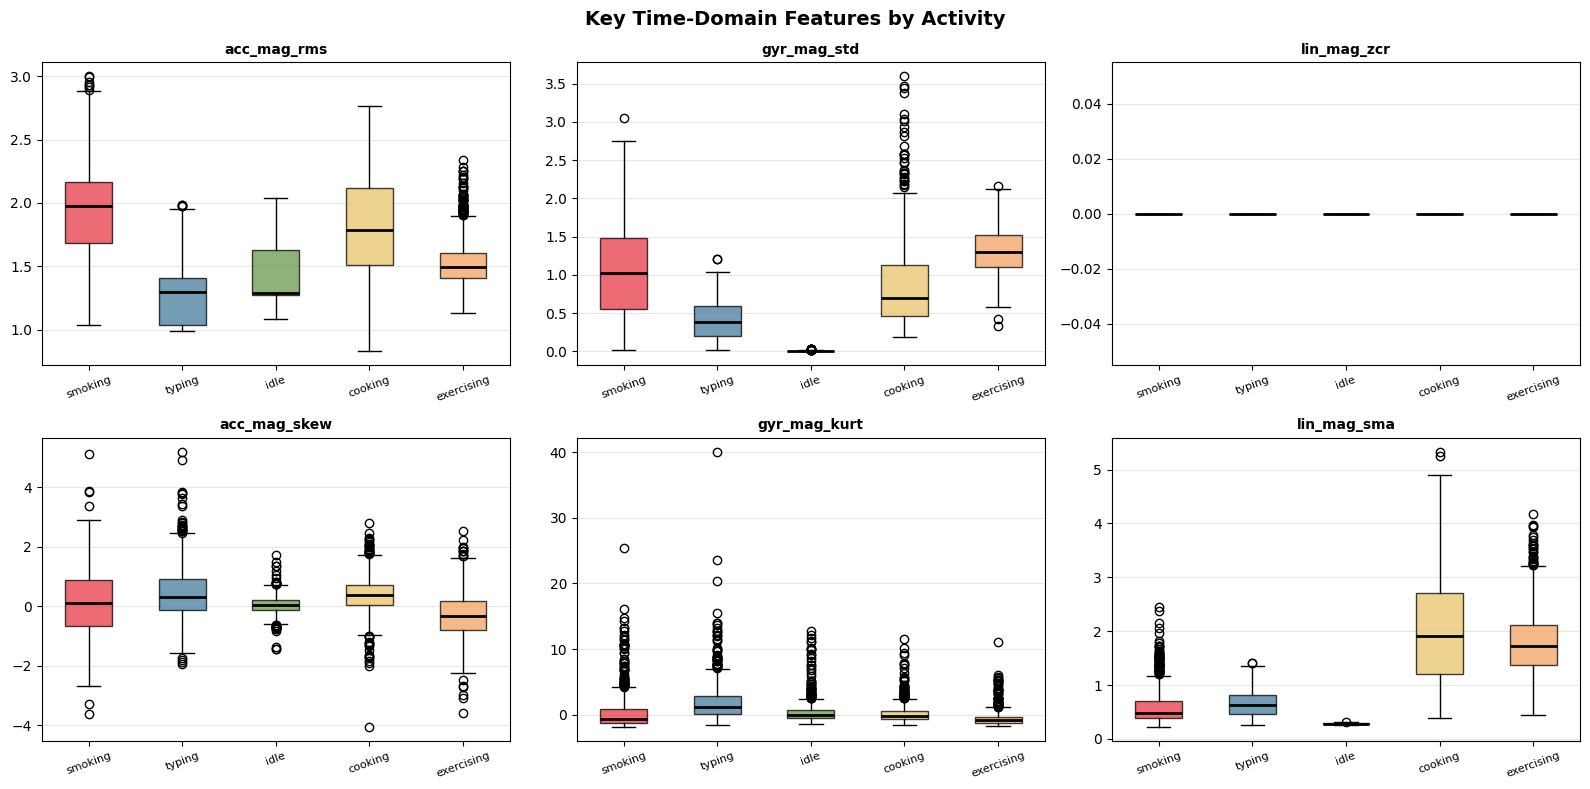

In [8]:
# ── Plot: Key time-domain features by activity ───────────────────────────────
key_features = ["acc_mag_rms", "gyr_mag_std", "lin_mag_zcr",
                "acc_mag_skew", "gyr_mag_kurt", "lin_mag_sma"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Key Time-Domain Features by Activity", fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flatten(), key_features):
    if feat not in feature_df.columns:
        ax.set_visible(False)
        continue
    data_to_plot = [feature_df[feature_df["label"]==act][feat].values
                    for act in ACTIVITIES]
    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
                    medianprops=dict(color="black", linewidth=2))
    for patch, act in zip(bp["boxes"], ACTIVITIES):
        patch.set_facecolor(PALETTE[act])
        patch.set_alpha(0.75)
    ax.set_title(feat, fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/eda/feature_distributions_time.png", dpi=150, bbox_inches="tight")
plt.show()


/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/2640816374.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/2640816374.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
/var/folders/lb/kl9ww49s0c7c8m8sknf2dgt40000gn/T/ipykernel_1833/2640816374.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
/var/folders/lb/kl9ww49s0c7c8m8sknf2d

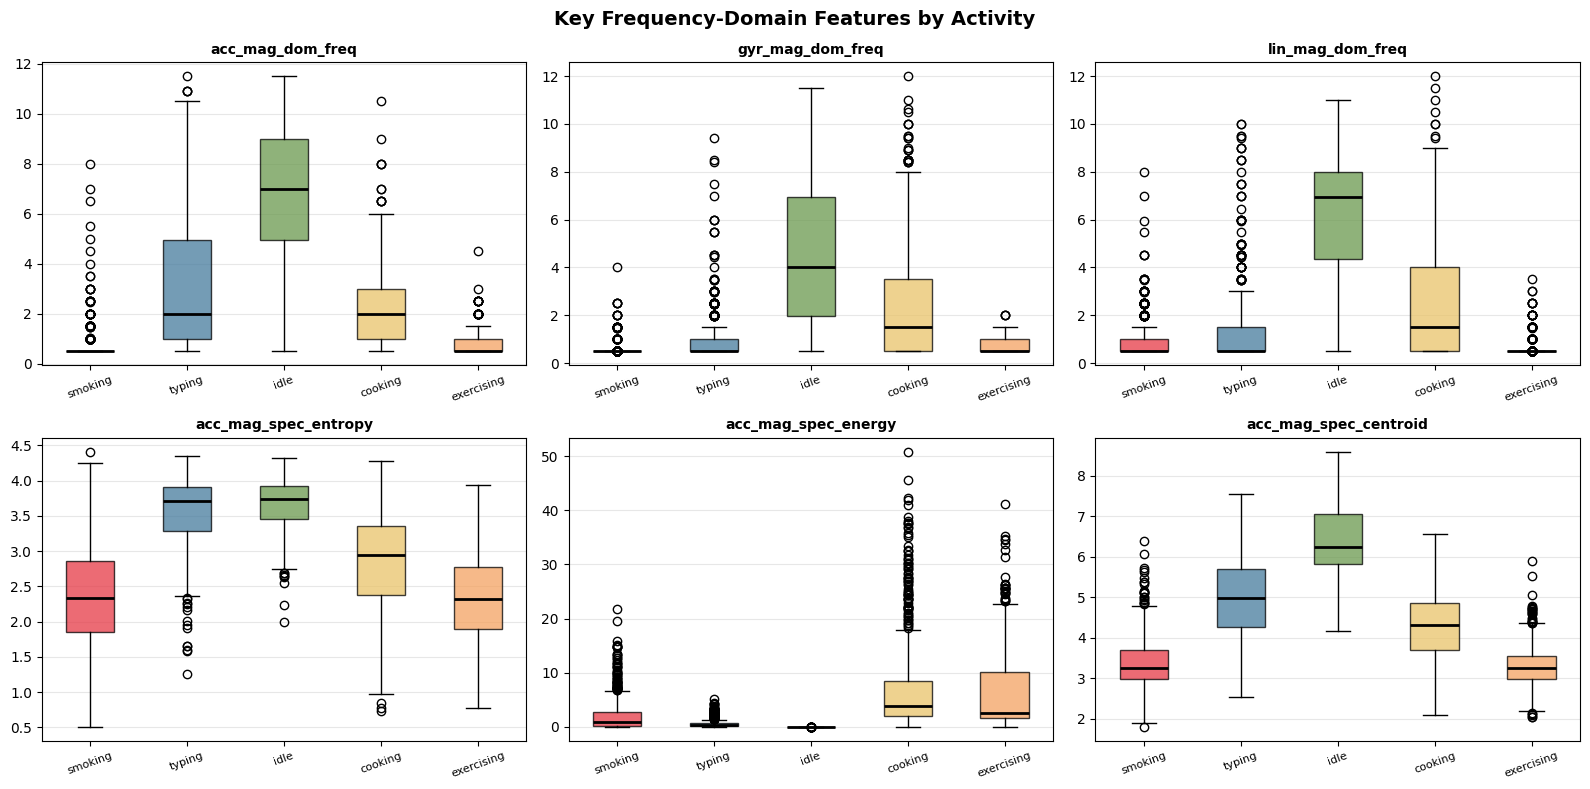

In [9]:
# ── Plot: Key frequency-domain features by activity ──────────────────────────
freq_features = ["acc_mag_dom_freq", "gyr_mag_dom_freq", "lin_mag_dom_freq",
                 "acc_mag_spec_entropy", "acc_mag_spec_energy", "acc_mag_spec_centroid"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
fig.suptitle("Key Frequency-Domain Features by Activity", fontsize=14, fontweight="bold")

for ax, feat in zip(axes.flatten(), freq_features):
    if feat not in feature_df.columns:
        ax.set_visible(False)
        continue
    data_to_plot = [feature_df[feature_df["label"]==act][feat].values
                    for act in ACTIVITIES]
    bp = ax.boxplot(data_to_plot, patch_artist=True, labels=ACTIVITIES,
                    medianprops=dict(color="black", linewidth=2))
    for patch, act in zip(bp["boxes"], ACTIVITIES):
        patch.set_facecolor(PALETTE[act])
        patch.set_alpha(0.75)
    ax.set_title(feat, fontweight="bold", fontsize=10)
    ax.tick_params(axis="x", rotation=20, labelsize=8)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/eda/feature_distributions_freq.png", dpi=150, bbox_inches="tight")
plt.show()


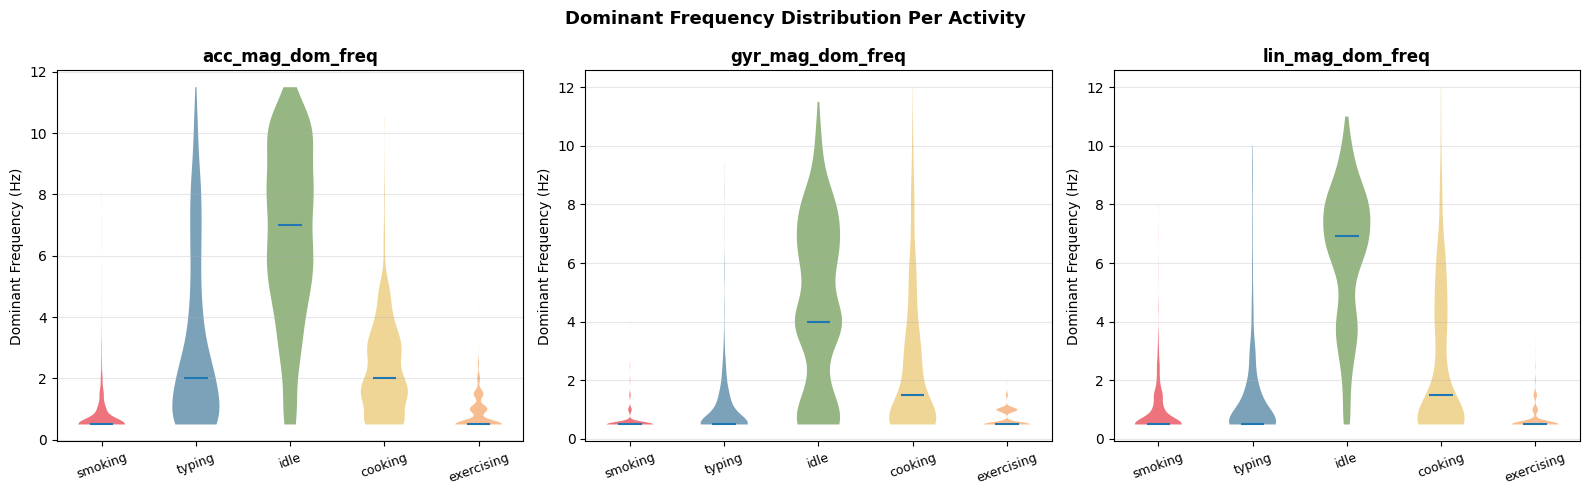

In [10]:
# ── Plot: Dominant frequency violin per activity ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dominant Frequency Distribution Per Activity",
             fontsize=13, fontweight="bold")

for ax, col in zip(axes, ["acc_mag_dom_freq","gyr_mag_dom_freq","lin_mag_dom_freq"]):
    data_to_plot = [feature_df[feature_df["label"]==act][col].values
                    for act in ACTIVITIES]
    parts = ax.violinplot(data_to_plot, showmedians=True, showextrema=False)
    for pc, act in zip(parts["bodies"], ACTIVITIES):
        pc.set_facecolor(PALETTE[act])
        pc.set_alpha(0.7)
    ax.set_xticks(range(1, len(ACTIVITIES)+1))
    ax.set_xticklabels(ACTIVITIES, rotation=20, fontsize=9)
    ax.set_title(col, fontweight="bold")
    ax.set_ylabel("Dominant Frequency (Hz)")
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/eda/dominant_frequency_violin.png", dpi=150, bbox_inches="tight")
plt.show()
# Expected: exercising ~0.6 Hz, smoking ~0.4 Hz, cooking ~2.6 Hz, typing ~2.2 Hz, idle ~noise


## 8 · Feature Correlation Heatmap — Identify Redundant Features

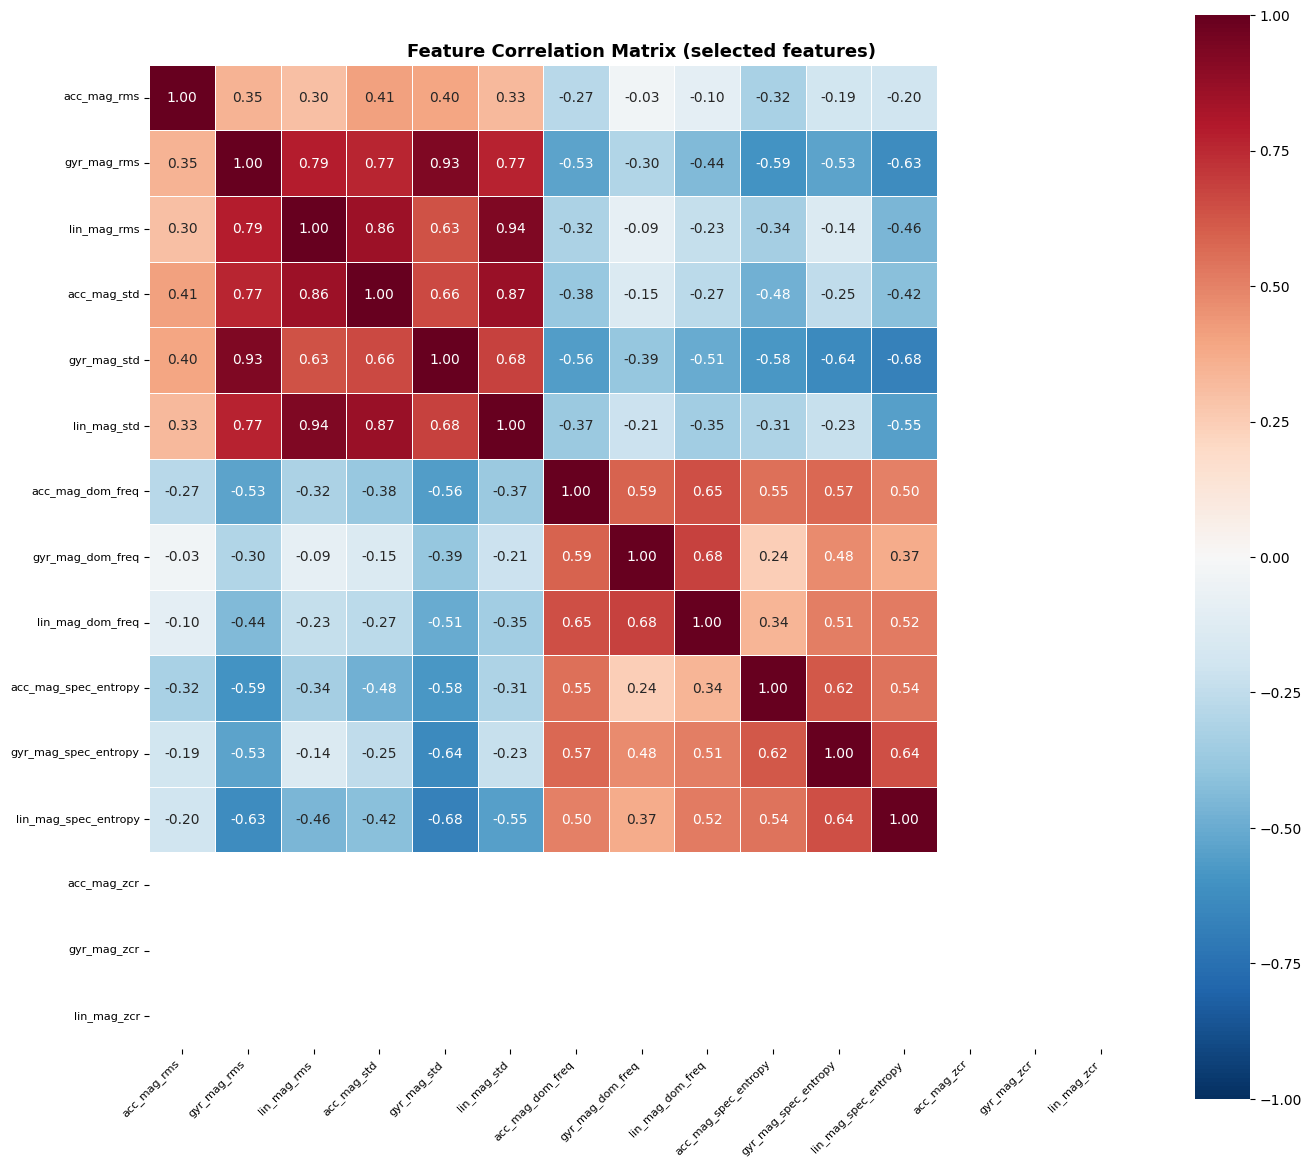

Features with |corr| > 0.95 (potentially redundant):


In [11]:
# Show correlation among a subset of key features
# High correlation = redundant features = candidates for removal
selected = ([f"{s}_rms"       for s in ["acc_mag","gyr_mag","lin_mag"]] +
            [f"{s}_std"       for s in ["acc_mag","gyr_mag","lin_mag"]] +
            [f"{s}_dom_freq"  for s in ["acc_mag","gyr_mag","lin_mag"]] +
            [f"{s}_spec_entropy" for s in ["acc_mag","gyr_mag","lin_mag"]] +
            [f"{s}_zcr"       for s in ["acc_mag","gyr_mag","lin_mag"]])

selected = [f for f in selected if f in feature_df.columns]
corr_matrix = feature_df[selected].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr_matrix, ax=ax, cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, annot=True, fmt=".2f",
            linewidths=0.5, square=True,
            xticklabels=selected, yticklabels=selected)
ax.set_title("Feature Correlation Matrix (selected features)",
             fontsize=13, fontweight="bold")
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig("outputs/eda/feature_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Features with |corr| > 0.95 (potentially redundant):")
for i in range(len(corr_matrix)):
    for j in range(i+1, len(corr_matrix)):
        if abs(corr_matrix.iloc[i,j]) > 0.95:
            print(f"  {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: "
                  f"{corr_matrix.iloc[i,j]:.3f}")


## 9 · Train / Test Split

Split by subject — subject_1 + subject_3 → train, subject_2 → test.


In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

feat_cols = [c for c in feature_df.columns
             if c not in ["label","subject","session"]]

# Split
train_feat = feature_df[feature_df["subject"].isin(["subject_1","subject_3"])].copy()
test_feat  = feature_df[feature_df["subject"] == "subject_2"].copy()

X_train = train_feat[feat_cols].values
X_test  = test_feat[feat_cols].values

# Encode labels
le = LabelEncoder()
le.fit(ACTIVITIES)
y_train = le.transform(train_feat["label"].values)
y_test  = le.transform(test_feat["label"].values)

# Normalise — fit on train only
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f"X_train : {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test  : {X_test.shape}   |  y_test : {y_test.shape}")
print(f"Features: {len(feat_cols)}")
print(f"Classes : {le.classes_}")
print(f"\nClass distribution (train):")
for i, act in enumerate(le.classes_):
    print(f"  {act:<12}: {(y_train==i).sum():,} windows")
print(f"\nClass distribution (test):")
for i, act in enumerate(le.classes_):
    print(f"  {act:<12}: {(y_test==i).sum():,} windows")


X_train : (2240, 249)  |  y_train: (2240,)
X_test  : (1120, 249)   |  y_test : (1120,)
Features: 249
Classes : ['cooking' 'exercising' 'idle' 'smoking' 'typing']

Class distribution (train):
  cooking     : 448 windows
  exercising  : 448 windows
  idle        : 448 windows
  smoking     : 448 windows
  typing      : 448 windows

Class distribution (test):
  cooking     : 224 windows
  exercising  : 224 windows
  idle        : 224 windows
  smoking     : 224 windows
  typing      : 224 windows


## 10 · Save Feature Matrix

In [13]:
import pickle

feature_df.to_parquet("outputs/features/feature_matrix.parquet", index=False)

# Save arrays and metadata for modelling notebook
np.save("outputs/features/X_train.npy", X_train)
np.save("outputs/features/X_test.npy",  X_test)
np.save("outputs/features/y_train.npy", y_train)
np.save("outputs/features/y_test.npy",  y_test)

with open("outputs/features/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
with open("outputs/features/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("outputs/features/feat_cols.pkl", "wb") as f:
    pickle.dump(feat_cols, f)

print("✅ Saved:")
print("  outputs/features/feature_matrix.parquet")
print("  outputs/features/X_train.npy  /  X_test.npy")
print("  outputs/features/y_train.npy  /  y_test.npy")
print("  outputs/features/label_encoder.pkl")
print("  outputs/features/scaler.pkl")
print("  outputs/features/feat_cols.pkl")
print(f"\nNext step → 03_modelling.ipynb")


✅ Saved:
  outputs/features/feature_matrix.parquet
  outputs/features/X_train.npy  /  X_test.npy
  outputs/features/y_train.npy  /  y_test.npy
  outputs/features/label_encoder.pkl
  outputs/features/scaler.pkl
  outputs/features/feat_cols.pkl

Next step → 03_modelling.ipynb
